# Full Model Comparison and Evaluation

Train and compare multiple classification models with consistent preprocessing.

This notebook orchestrates the complete training pipeline:
1. Load and clean data
2. Split features and target  
3. Create preprocessing pipeline
4. Train multiple models
5. Evaluate and rank models
6. Save best model and artifacts

In [13]:
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

# Add src to path
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

# Import training functions
from models.train_model import (
    load_data,
    basic_clean,
    split_features_target,
    make_preprocessor,
    train_and_evaluate_models,
    rank_models,
    save_artifacts,
    save_preprocessed_data
)

# Import plotting functions
from visualization.plots import (
    plot_model_comparison,
    plot_shap_summary,
    plot_confusion_matrix,
    plot_roc_curves
)

# Set up paths
DATA_RAW = ROOT / 'data' / 'raw' / 'heart.csv'
MODELS_DIR = ROOT / 'results' / 'models'
FIGURES_DIR = ROOT / 'results' / 'figures'

# Configure visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f"✓ Setup complete")
print(f"  Root: {ROOT}")
print(f"  Data: {DATA_RAW}")
print(f"  Models: {MODELS_DIR}")
print(f"  Figures: {FIGURES_DIR}")


✓ Setup complete
  Root: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction
  Data: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\data\raw\heart.csv
  Models: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\models
  Figures: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures


## Step 1: Load and Clean Data

Load the raw heart disease dataset and perform basic cleaning (remove duplicates, handle missing values, fix data types).

In [14]:
# Load and clean data
print("[STEP 1] Loading and Cleaning Data")
print("-" * 80)

df = load_data(str(DATA_RAW))
df = basic_clean(df)

print(f"\nDataset shape: {df.shape}")
print(f"Data types:\n{df.dtypes}")
print(f"\nFirst few rows:")
df.head()

[STEP 1] Loading and Cleaning Data
--------------------------------------------------------------------------------
✓ Loaded 918 records, 12 features from C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\data\raw\heart.csv
  ✓ No duplicates found
  ✓ No missing values
  ✓ Cleaned dataset: 918 records, 12 features

Dataset shape: (918, 12)
Data types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

First few rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Step 2: Split Features and Target

Separate features (X) from target variable (y), then split into train and test sets with stratification.

In [15]:
print("\n[STEP 2] Split Features and Target")
print("-" * 80)

# Split features and target
X, y = split_features_target(df, target_col='HeartDisease')

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n✓ Train set: {X_train.shape[0]} records")
print(f"✓ Test set: {X_test.shape[0]} records")
print(f"\nTrain class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())


[STEP 2] Split Features and Target
--------------------------------------------------------------------------------
✓ Features: 11 | Target: HeartDisease
  Class distribution: {1: 508, 0: 410}

✓ Train set: 734 records
✓ Test set: 184 records

Train class distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64

Test class distribution:
HeartDisease
1    102
0     82
Name: count, dtype: int64


## Step 3: Create Preprocessing Pipeline

Create a ColumnTransformer that standardizes numeric features and one-hot encodes categorical features.

In [16]:
print("\n[STEP 3] Create Preprocessing Pipeline")
print("-" * 80)

# Create preprocessor (ColumnTransformer with StandardScaler + OneHotEncoder)
preprocessor = make_preprocessor(X_train)

print(f"\n✓ Preprocessor fitted on {X_train.shape[0]} training records")


[STEP 3] Create Preprocessing Pipeline
--------------------------------------------------------------------------------
✓ Numeric features (6): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
✓ Categorical features (5): ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
✓ Preprocessor created and fitted

✓ Preprocessor fitted on 734 training records


## Step 4: Train and Evaluate Multiple Models

Train multiple classification models (Logistic Regression, Random Forest, XGBoost, LightGBM, CatBoost) and evaluate with standard metrics.

In [17]:
print("\n[STEP 4] Train and Evaluate Models")
print("-" * 80)

# Train models and get results
results_df, fitted_models = train_and_evaluate_models(
    X_train, y_train,
    X_test, y_test,
    preprocessor
)

print(f"\n✓ Trained {len(fitted_models)} models")
print(f"\nModel Results:")
print(results_df.to_string(index=False))


[STEP 4] Train and Evaluate Models
--------------------------------------------------------------------------------

TRAINING MODELS

▶ Training LogisticRegression...
  ✓ Accuracy:  0.8859
  ✓ Precision: 0.8716
  ✓ Recall:    0.9314
  ✓ F1-Score:  0.9005
  ✓ ROC-AUC:   0.9308

▶ Training RandomForest...
  ✓ Accuracy:  0.8696
  ✓ Precision: 0.8750
  ✓ Recall:    0.8922
  ✓ F1-Score:  0.8835
  ✓ ROC-AUC:   0.9314

▶ Training XGBoost...
  ✓ Accuracy:  0.8587
  ✓ Precision: 0.8725
  ✓ Recall:    0.8725
  ✓ F1-Score:  0.8725
  ✓ ROC-AUC:   0.9219

▶ Training LightGBM...
  ✓ Accuracy:  0.8587
  ✓ Precision: 0.8654
  ✓ Recall:    0.8824
  ✓ F1-Score:  0.8738
  ✓ ROC-AUC:   0.9235

▶ Training CatBoost...
  ✓ Accuracy:  0.8913
  ✓ Precision: 0.9020
  ✓ Recall:    0.9020
  ✓ F1-Score:  0.9020
  ✓ ROC-AUC:   0.9377

MODEL COMPARISON
             Model  accuracy  precision   recall       f1  roc_auc
          CatBoost  0.891304   0.901961 0.901961 0.901961 0.937709
LogisticRegression  0.885870   

## Step 5: Rank and Select Best Model

Rank models by F1-score (primary) and ROC-AUC (tiebreaker) to identify the best performer.

In [21]:
print("\n[STEP 5] Rank Models and Select Best")
print("-" * 80)

# Force reload of train_model module to get latest function signatures
import importlib
import models.train_model
importlib.reload(models.train_model)
from models.train_model import rank_models as rank_models_fresh

# Rank models and get top 3
best_model_name, top_models = rank_models_fresh(results_df)
best_model = fitted_models[best_model_name]
best_metrics = results_df[results_df['Model'] == best_model_name].iloc[0].to_dict()

print(f"\n{best_model_name} selected as best model")
print(f"Metrics: {best_metrics}")



[STEP 5] Rank Models and Select Best
--------------------------------------------------------------------------------

✓ Best Model: CatBoost
  F1-Score: 0.9020
  ROC-AUC:  0.9377

✓ Top 3 models for hyperparameter tuning:
  1. CatBoost: F1=0.9020
  2. LogisticRegression: F1=0.9005
  3. RandomForest: F1=0.8835

CatBoost selected as best model
Metrics: {'Model': 'CatBoost', 'accuracy': 0.8913043478260869, 'precision': 0.9019607843137255, 'recall': 0.9019607843137255, 'f1': 0.9019607843137255, 'roc_auc': 0.9377092300334768}


## Step 6: Save All Artifacts

Save the best model, preprocessor, metadata, preprocessed data, and comparison results.

In [22]:
print("\n[STEP 6] Save Artifacts")
print("-" * 80)

# Force reload to get latest function versions
import importlib
import models.train_model
importlib.reload(models.train_model)
from models.train_model import (
    tune_hyperparameters,
    compute_shap_values,
    compute_feature_importance,
    save_artifacts as save_artifacts_fresh
)

# Initialize containers (will be filled by tuning step)
tuned_params = {}
feature_importance = {}
shap_values = None

# Hyperparameter tuning
best_model_name_tuned, best_model_tuned, tuned_params = tune_hyperparameters(
    X_train, y_train, X_test, y_test, preprocessor, 
    top_models, fitted_models, n_trials=50
)

# Update best model if tuning improved it
if best_model_name_tuned != best_model_name:
    print(f"\n✓ Tuning selected {best_model_name_tuned} (improvement from {best_model_name})")
    best_model = best_model_tuned
    best_model_name = best_model_name_tuned
    best_metrics = results_df[results_df['Model'] == best_model_name].iloc[0].to_dict()
else:
    best_model = best_model_tuned

# Compute SHAP values and feature importance
shap_values, feature_names = compute_shap_values(best_model, X_train, X_test, path=str(FIGURES_DIR))
feature_importance = compute_feature_importance(best_model, X_train, X_test, shap_values, feature_names)

print(f"\n✓ Top 10 Most Important Features:")
for i, (feature, importance) in enumerate(list(feature_importance.items())[:10], 1):
    print(f"  {i}. {feature}: {importance:.4f}")

# Save trained model, preprocessor, metadata, and SHAP values
save_artifacts_fresh(
    best_model, preprocessor, best_metrics, 
    path=str(MODELS_DIR),
    tuned_params=tuned_params,
    feature_importance=feature_importance,
    shap_values=shap_values
)

# Save model comparison results to results/models
results_csv_path = MODELS_DIR / "model_comparison.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"✓ Saved model comparison: {results_csv_path}")

# Save preprocessed data
save_preprocessed_data(X_train, y_train, X_test, y_test, preprocessor, path=str(ROOT / 'data' / 'processed'))

print(f"\n✓ All artifacts saved successfully")


[I 2026-03-15 20:59:29,540] A new study created in memory with name: no-name-990e1049-866c-49fd-8d4b-80c922bc0fbb



[STEP 6] Save Artifacts
--------------------------------------------------------------------------------

HYPERPARAMETER TUNING WITH OPTUNA

▶ Tuning CatBoost (n_trials=50)...


[I 2026-03-15 20:59:30,217] Trial 0 finished with value: 0.87 and parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'iterations': 233}. Best is trial 0 with value: 0.87.
[I 2026-03-15 20:59:30,598] Trial 1 finished with value: 0.8285714285714286 and parameters: {'depth': 8, 'learning_rate': 0.01700037298921102, 'iterations': 89}. Best is trial 0 with value: 0.87.
[I 2026-03-15 20:59:30,914] Trial 2 finished with value: 0.8656716417910447 and parameters: {'depth': 4, 'learning_rate': 0.19030368381735815, 'iterations': 200}. Best is trial 0 with value: 0.87.
[I 2026-03-15 20:59:32,160] Trial 3 finished with value: 0.8975609756097561 and parameters: {'depth': 8, 'learning_rate': 0.010725209743171996, 'iterations': 293}. Best is trial 3 with value: 0.8975609756097561.
[I 2026-03-15 20:59:32,629] Trial 4 finished with value: 0.8246445497630331 and parameters: {'depth': 9, 'learning_rate': 0.020589728197687916, 'iterations': 95}. Best is trial 3 with value: 0.8975609756097561.
[I

  ✓ Best F1: 0.9073
  ✓ Best hyperparameters from trial 21:
    - depth: 7
    - learning_rate: 0.20749887431017747
    - iterations: 112

▶ Tuning LogisticRegression (n_trials=50)...


[I 2026-03-15 20:59:55,023] Trial 7 finished with value: 0.8682926829268293 and parameters: {'C': 0.004982752357076452, 'solver': 'liblinear'}. Best is trial 1 with value: 0.9004739336492891.
[I 2026-03-15 20:59:55,072] Trial 8 finished with value: 0.9004739336492891 and parameters: {'C': 0.19069966103000435, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.9004739336492891.
[I 2026-03-15 20:59:55,116] Trial 9 finished with value: 0.8962264150943396 and parameters: {'C': 0.37253938395788866, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.9004739336492891.
[I 2026-03-15 20:59:55,153] Trial 10 finished with value: 0.9004739336492891 and parameters: {'C': 58.607239983060765, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.9004739336492891.
[I 2026-03-15 20:59:55,178] Trial 11 finished with value: 0.9004739336492891 and parameters: {'C': 3.0240503427727234, 'solver': 'liblinear'}. Best is trial 1 with value: 0.9004739336492891.
[I 2026-03-15 20:59:55,214] Trial 12 finished with value

  ✓ Best F1: 0.9005
  ✓ Best hyperparameters from trial 1:
    - C: 0.9846738873614566
    - solver: lbfgs

▶ Tuning RandomForest (n_trials=50)...


[I 2026-03-15 20:59:57,019] Trial 0 finished with value: 0.8942307692307693 and parameters: {'n_estimators': 144, 'max_depth': 29, 'min_samples_split': 8}. Best is trial 0 with value: 0.8942307692307693.
[I 2026-03-15 20:59:57,511] Trial 1 finished with value: 0.8975609756097561 and parameters: {'n_estimators': 200, 'max_depth': 9, 'min_samples_split': 3}. Best is trial 1 with value: 0.8975609756097561.
[I 2026-03-15 20:59:57,724] Trial 2 finished with value: 0.8932038834951457 and parameters: {'n_estimators': 64, 'max_depth': 27, 'min_samples_split': 7}. Best is trial 1 with value: 0.8975609756097561.
[I 2026-03-15 20:59:58,229] Trial 3 finished with value: 0.8720379146919431 and parameters: {'n_estimators': 227, 'max_depth': 5, 'min_samples_split': 10}. Best is trial 1 with value: 0.8975609756097561.
[I 2026-03-15 20:59:58,909] Trial 4 finished with value: 0.8932038834951457 and parameters: {'n_estimators': 258, 'max_depth': 10, 'min_samples_split': 3}. Best is trial 1 with value: 0.

  ✓ Best F1: 0.9038
  ✓ Best hyperparameters from trial 49:
    - n_estimators: 130
    - max_depth: 9
    - min_samples_split: 5

✓ Best Tuned Model: CatBoost
  F1-Score: 0.9073

COMPUTING SHAP VALUES
✓ Feature names: 15 features
✓ Created KernelExplainer


  0%|          | 0/184 [00:00<?, ?it/s]

✓ Computed SHAP values: (184, 15)
✓ Saved SHAP summary plot: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures\shap_summary.png

✓ Top 10 Most Important Features:
  1. ST_Slope_Up: 0.1678
  2. Oldpeak: 0.0693
  3. Sex_M: 0.0607
  4. Cholesterol: 0.0601
  5. ST_Slope_Flat: 0.0577
  6. ExerciseAngina_Y: 0.0503
  7. MaxHR: 0.0410
  8. ChestPainType_NAP: 0.0397
  9. ChestPainType_ATA: 0.0313
  10. FastingBS: 0.0269

SAVING ARTIFACTS
✓ Saved model: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\models\best_model.joblib
✓ Saved preprocessor: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\models\preprocessor.joblib
✓ Saved SHAP values: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\models\shap_values.joblib
✓ Saved metadata: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\models\metadata.json
✓ Saved model comparison: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\models\model_comparison.csv

S

## Step 7: Visualization - Model Comparison

Create comparative visualizations of model performance metrics.


[VISUALIZATION STEP] Create Model Comparison Plots
--------------------------------------------------------------------------------


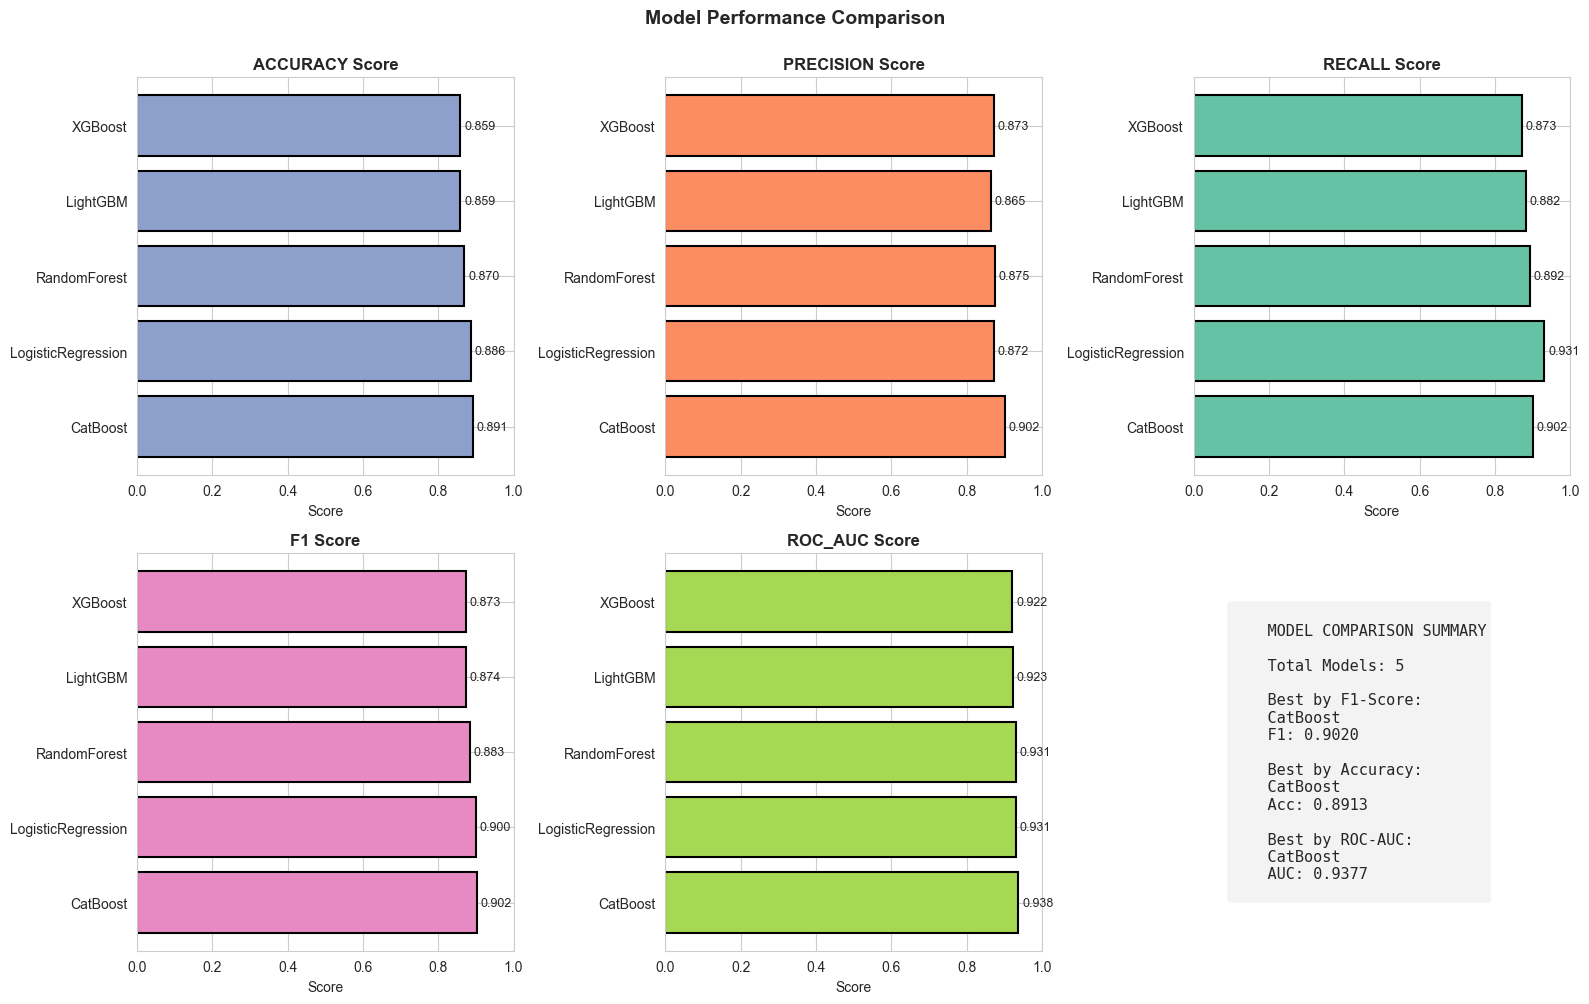

✓ Saved: model_comparison_20260315_211259.png
✓ Model comparison saved to: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures\model_comparison_20260315_211259.png


In [23]:
print("\n[VISUALIZATION STEP] Create Model Comparison Plots")
print("-" * 80)

# Use reusable function for model comparison
comparison_plot = plot_model_comparison(results_df, save_name='model_comparison')
print(f"✓ Model comparison saved to: {comparison_plot}")


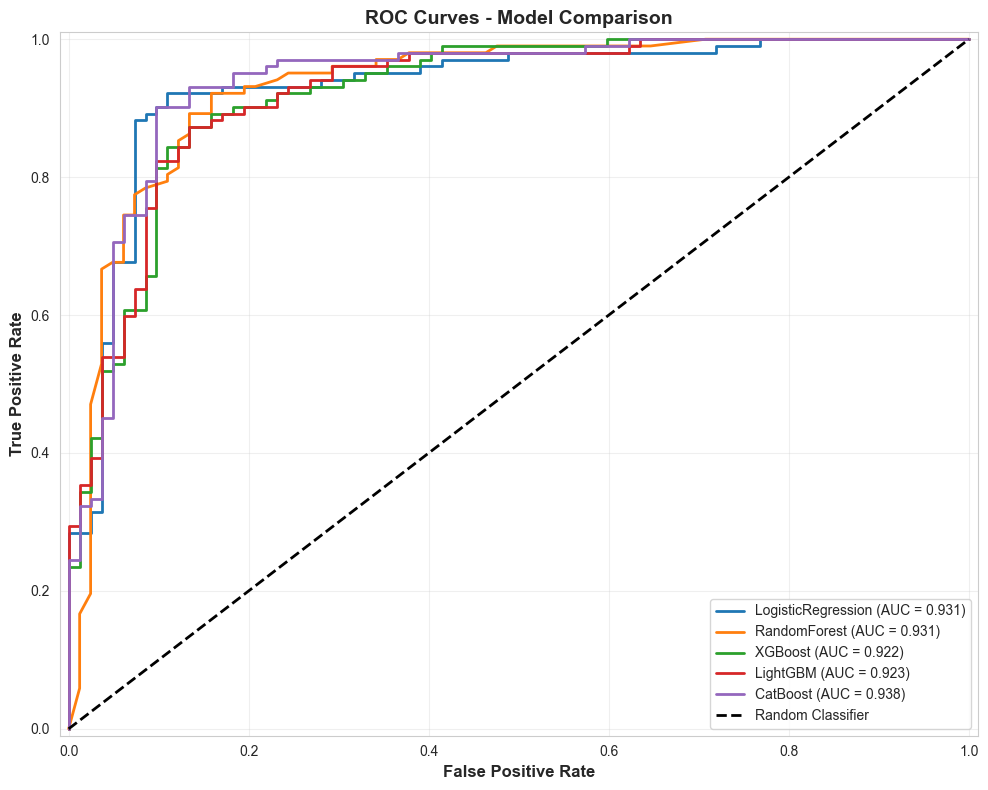

✓ Saved: roc_curves_20260315_211300.png
✓ ROC curves saved to: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures\roc_curves_20260315_211300.png


In [24]:
# ROC Curves for all models
roc_plot = plot_roc_curves(
    models_dict=fitted_models,
    X_test=X_test,
    y_test=y_test,
    preprocessor=preprocessor,
    save_name='roc_curves'
)
print(f"✓ ROC curves saved to: {roc_plot}")


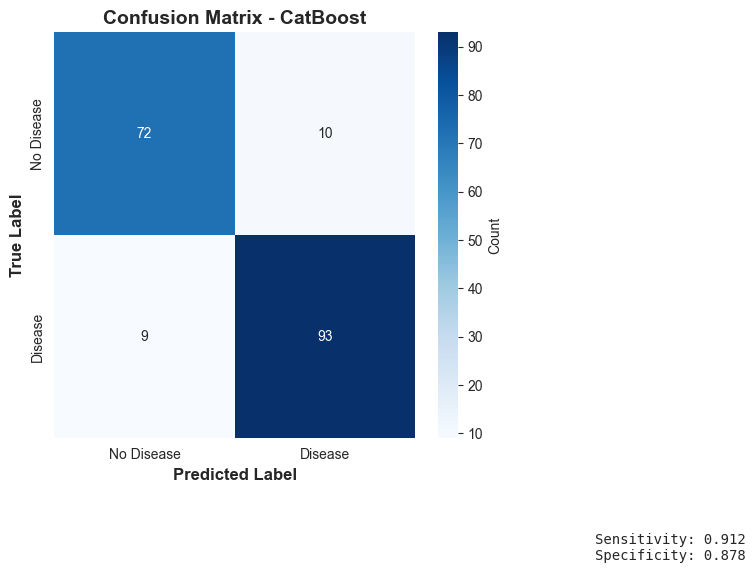

✓ Saved: confusion_matrix_20260315_211301.png
✓ Confusion matrix saved to: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures\confusion_matrix_20260315_211301.png

Generating SHAP summary plot...


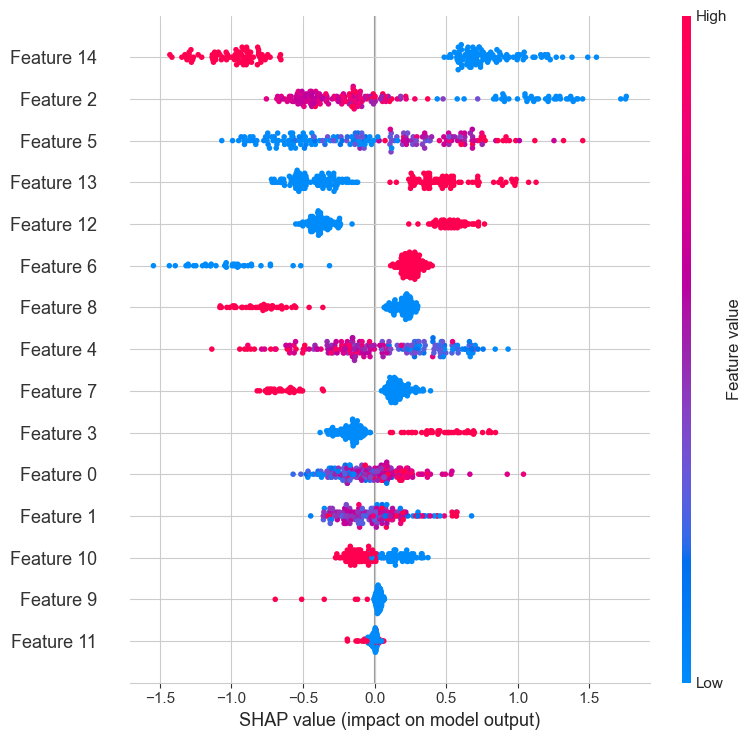

✓ Saved: shap_summary_20260315_211302.png
✓ SHAP summary saved to: C:\Users\Ruhaan Kakar\Desktop\Heart-Disease-Prediction\results\figures\shap_summary_20260315_211302.png


In [25]:
# Confusion Matrix for best model
y_pred_best = best_model.predict(X_test)
cm_plot = plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred_best,
    model_name=best_model_name,
    save_name='confusion_matrix'
)
print(f"✓ Confusion matrix saved to: {cm_plot}")

# SHAP Summary Plot for best model
print("\nGenerating SHAP summary plot...")
shap_plot = plot_shap_summary(
    model=best_model,
    X_train=X_train,
    X_test=X_test,
    save_name='shap_summary'
)
if shap_plot:
    print(f"✓ SHAP summary saved to: {shap_plot}")
else:
    print("⚠ SHAP plot could not be generated")


## Summary

Complete training and evaluation pipeline executed successfully.

In [26]:
print("\n" + "="*80)
print("TRAINING PIPELINE COMPLETED")
print("="*80)

print(f"""
✓ DATA PROCESSING
  • Raw records: {len(df)}
  • Features: {X.shape[1]}
  • Train set: {X_train.shape[0]} records
  • Test set: {X_test.shape[0]} records

✓ MODEL DEVELOPMENT
  • Models trained: {len(fitted_models)}
  • Top models tuned: {len(top_models)}
  • Optuna trials: 50 per model
  • Best model: {best_model_name}
  • F1-Score: {best_metrics['f1']:.4f}
  • Accuracy: {best_metrics['accuracy']:.4f}
  • ROC-AUC: {best_metrics['roc_auc']:.4f}

✓ EXPLAINABILITY
  • SHAP values computed ✓
  • Feature importance ranking: {len(feature_importance)} features
  • Top 3 features:
""")

for i, (feature, importance) in enumerate(list(feature_importance.items())[:3], 1):
    print(f"    {i}. {feature}: {importance:.4f}")

print(f"""
✓ VISUALIZATIONS CREATED (Timestamped)
  • Model Comparison: results/figures/model_comparison_*.png
  • ROC Curves: results/figures/roc_curves_*.png
  • Confusion Matrix: results/figures/confusion_matrix_*.png
  • SHAP Summary: results/figures/shap_summary_*.png

✓ ARTIFACTS SAVED
  • Model: results/models/best_model.joblib
  • Preprocessor: results/models/preprocessor.joblib
  • Metadata: results/models/metadata.json (with hyperparams + feature importance)
  • SHAP values: results/models/shap_values.joblib
  • Comparison: results/models/model_comparison.csv
  • Train data: data/processed/train_processed.csv
  • Test data: data/processed/test_processed.csv

✓ NEXT STEPS
  • Use predict.py for predictions on new data
  • Review metadata.json for hyperparameters
  • Analyze timestamped visualizations for model interpretability
  • Review feature_importance data for key drivers
""")

print("="*80)



TRAINING PIPELINE COMPLETED

✓ DATA PROCESSING
  • Raw records: 918
  • Features: 11
  • Train set: 734 records
  • Test set: 184 records

✓ MODEL DEVELOPMENT
  • Models trained: 5
  • Top models tuned: 3
  • Optuna trials: 50 per model
  • Best model: CatBoost
  • F1-Score: 0.9020
  • Accuracy: 0.8913
  • ROC-AUC: 0.9377

✓ EXPLAINABILITY
  • SHAP values computed ✓
  • Feature importance ranking: 15 features
  • Top 3 features:

    1. ST_Slope_Up: 0.1678
    2. Oldpeak: 0.0693
    3. Sex_M: 0.0607

✓ VISUALIZATIONS CREATED (Timestamped)
  • Model Comparison: results/figures/model_comparison_*.png
  • ROC Curves: results/figures/roc_curves_*.png
  • Confusion Matrix: results/figures/confusion_matrix_*.png
  • SHAP Summary: results/figures/shap_summary_*.png

✓ ARTIFACTS SAVED
  • Model: results/models/best_model.joblib
  • Preprocessor: results/models/preprocessor.joblib
  • Metadata: results/models/metadata.json (with hyperparams + feature importance)
  • SHAP values: results/models